# Replicating Machnes paper results
## 1. Ideal pulse sequence.
First, the paper describes an ideal pulse sequence. Assuming $\eta\Omega \gg \nu$ and ignoring the free evolution for the duration of the pulses, the trotter cycle described in Machnes et al. consists of the following steps:
* $X\sigma_{y}$ pulse for dt
 $$
 H_{X\sigma_{y}} = \eta \Omega_T (a + a^{\dagger}) \sigma_{y}
$$
* Free evolution for dt
 $$
 H_{free} = \nu (a^{\dagger}a + \frac{1}{2})
 $$
 * $-X\sigma_{y}$ pulse for dt
 $$
    H_{-X\sigma_{y}} = -\eta \Omega_T (a + a^{\dagger}) \sigma_{y}
$$ 
* $X\sigma_{x}$ pulse for dt
 $$
 H_{X\sigma_{x}} = \eta \Omega_T (a + a^{\dagger}) \sigma_{x}
$$


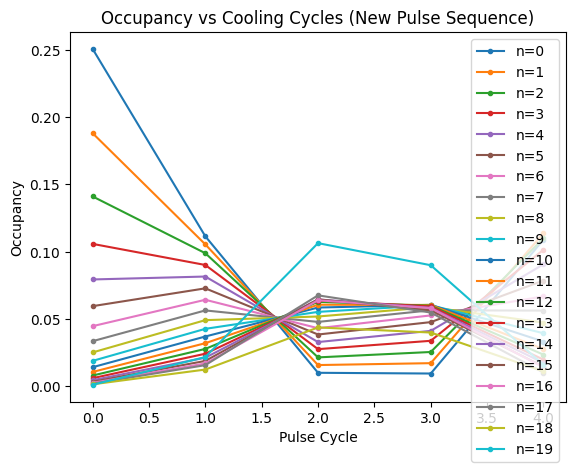

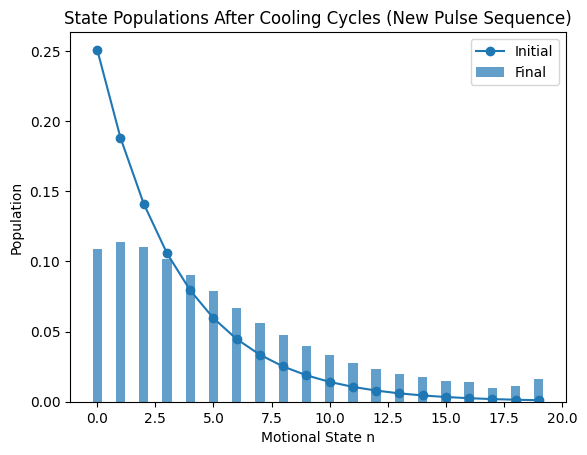

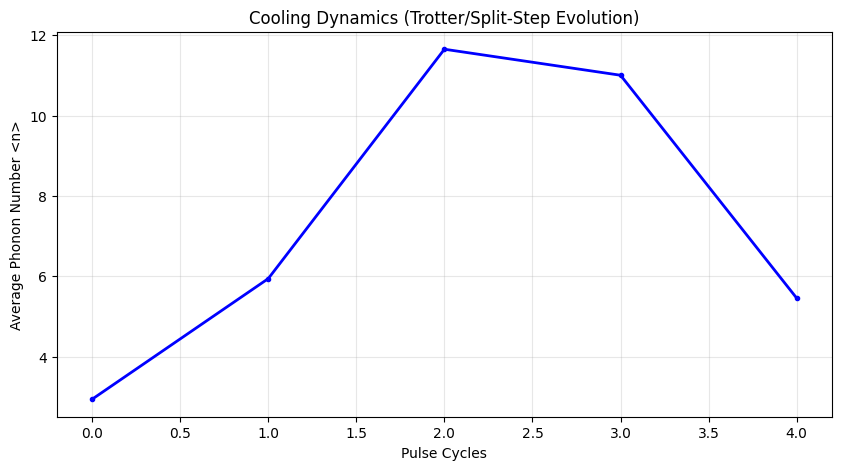

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 1  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
eta = 0.1   # Lamb-Dicke parameter
N = 20  # Truncation for the Fock space
n_trotter = 180  # Number of Trotter cycles 
num_pulses = 4       
Omega_T = 1000  # Boosting Omega to approach Strong Coupling [cite: 10]
n_thermal = 3  # Average thermal phonon number
Omega = nu
n0 = 1
gamma = 5  # Spin relaxation
kT = 100      # Boltzmann constant times temperature

# --- FIX: Pulse parameters ---
tau_free =  10 # Ratio of free evolution to pulse duration
# Pulse duration from condition
total_time = 1
dt = total_time / (tau_free * Omega_T)

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))
X_op = a_full + a_dag_full

"""Trotter pulse sequence Hamiltonians"""

# 1) X sy pulse Hamiltonian
H_Y = eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y = liouvillian(H_Y)
U_Y = (L_Y * dt).expm()

# 2) Free evolution Hamiltonian
H_free = nu * (a_dag_full * a_full + 1/2)
L_free = liouvillian(H_free)
U_free = (L_free * tau_free * dt).expm()

# 3) Y -sy pulse Hamiltonian
# FIX: Use eta instead of nu
H_Y_undo = -eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y_undo = liouvillian(H_Y_undo)
U_Y_undo = (L_Y_undo * dt).expm()

# 4) Another X sx pulse Hamiltonian
H_X_sx = eta * Omega_T * (a_full + a_dag_full) * s_x_full
L_X_sx = liouvillian(H_X_sx)
U_X_sx = (L_X_sx * dt).expm()

# Build the full propagator for one Trotter cycle
# prop_trotter = U_Y * U_free * U_Y
prop_trotter = U_Y_undo * U_free * U_Y * U_X_sx

# Add a relaxation step to reinitiate the internal dof
c_op = np.sqrt(gamma * (1 + n0)) * s_minus_full
L_relax = liouvillian(0 * s_z_full, [c_op])
U_relax = (L_relax * dt).expm()
prop_cycle = U_relax * U_X_sx * (prop_trotter**n_trotter)

times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles

# Initial state: spin in ground, motion thermal
thermal_state = thermal_dm(N, n_thermal)
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# Storage
occupancies_fast = np.zeros((num_pulses + 1, N))
rho_current = operator_to_vector(initial_state)

# Initial occupancy
occupancies_fast[0, :] = initial_state.ptrace(1).diag().real
# Calculate initial energy
n_start = expect(a_dag_full * a_full, initial_state)
avg_energy = []
avg_energy.append(n_start)

# Evolve step-by-step under the new pulse sequence
for k in range(1, num_pulses + 1):
    rho_current = prop_cycle * rho_current
    
    # Store data
    rho_mat = vector_to_operator(rho_current)
    n_avg = expect(a_dag_full * a_full, rho_mat)
    avg_energy.append(n_avg)
    occupancies_fast[k, :] = rho_mat.ptrace(1).diag().real

# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies_fast[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies_fast[0, :]
p_motional_final = occupancies_fast[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Plot average phonon number over cycles
plt.figure(figsize=(10, 5))
plt.plot(range(num_pulses + 1), avg_energy, 'b.-', linewidth=2)
plt.xlabel('Pulse Cycles')
plt.ylabel('Average Phonon Number <n>')
plt.title('Cooling Dynamics (Trotter/Split-Step Evolution)')
plt.grid(True, alpha=0.3)
plt.show()

### 2. Trotter cycle implemented in our sequence.
In our implementation, we have the following steps:

* RF dipolar pulse to the trapped ion
* Y pulse of pi/2
* x pulse of length $\tau$
* undo y pulse
* Relacation to ground spin state
* undo displacement RF pulse

In this frame, $\Omega = \nu$ and $\Delta = 0$

Pulse duration tau: 31.41592653589793


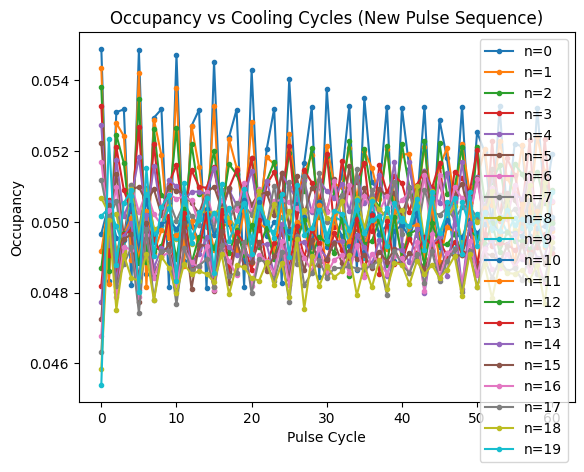

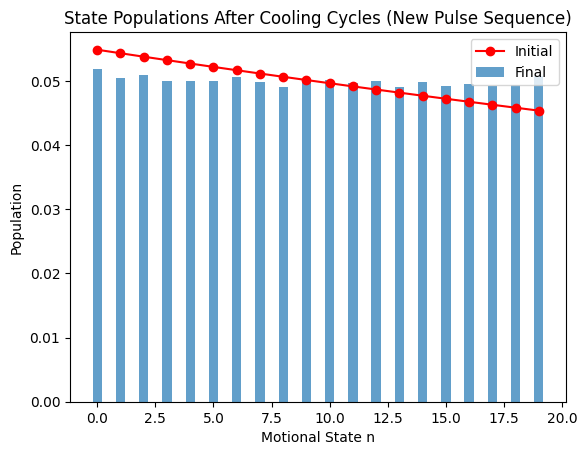

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 0  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
Omega = nu  # Rabi frequency
Omega_y = 1000  # Rabi frequency for Y pulse
eta = 0.2   # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
kT = 100      # Boltzmann constant times temperature
tau =  2*np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration
print(f"Pulse duration tau: {tau}")
# Define operators
N = 20  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))

# Displaced Hamiltonian operator
D_op = tensor(qeye(2), displace(N,1j*eta))

"""Hamiltonians for pulse and dissipation steps defined above."""

# Full Hamiltonian (Eq. 1) – not directly used in the new sequence,
## but kept for reference
# H_pulse = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
#           0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())

# Keep for reference
# H_pulse = nu * a_dag_full * a_full + 1j * 0.5 * eta * Omega * s_x_full * (a_full - a_dag_full)  + Omega/2 * s_z_full

# Hamiltonian (Free evolution for Dissipation)
H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

# --- Pulses for the new sequence ---

# 1) RF dipolar pulse of i*eta/2
H_rf = (RF_strength / 2) * (a_full + a_dag_full)
rf_duration = eta / RF_strength
L_rf = liouvillian(H_rf, [])
prop_rf = (L_rf * rf_duration).expm()
# undo RF
prop_rf_undo = (-L_rf * rf_duration).expm()
 
# 2) Y(π/2) pulse on the spin, same as H_pulse but with phase shift on the sigmas
#H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
#          0.5 * Omega_y *(-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
H_y = 0.5 * Omega_y *s_y_full
y_duration = np.pi / (2 *Omega_y)
L_y = liouvillian(H_y, [])
prop_y = (L_y * y_duration).expm()
# Undo Y(π/2)
L_y_undo = liouvillian(-H_y, [])
prop_y_undo = (L_y_undo * y_duration).expm()
 
 
# 3) Effective X(τ) pulse implemented via Trotter sequence (standalone)
# Trotter sequence parameters (copied so this cell is self-contained)
n_trotter = 180  # Number of Trotter cycles
tau_free = 10    # Ratio of free evolution to pulse duration
Omega_T = 1000   # Trotter drive strength (as in ideal sequence)
total_time = 1
dt = total_time / (tau_free * Omega_T)

# Trotter pulse sequence Hamiltonians (ideal Machnes cycle)
H_Y_trot = eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y_trot = liouvillian(H_Y_trot)
U_Y_trot = (L_Y_trot * dt).expm()

H_free_trot = nu * (a_dag_full * a_full + 1/2)
L_free_trot = liouvillian(H_free_trot)
U_free_trot = (L_free_trot * tau_free * dt).expm()

H_Y_undo_trot = -eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y_undo_trot = liouvillian(H_Y_undo_trot)
U_Y_undo_trot = (L_Y_undo_trot * dt).expm()

H_X_sx_trot = eta * Omega_T * (a_full + a_dag_full) * s_x_full
L_X_sx_trot = liouvillian(H_X_sx_trot)
U_X_sx_trot = (L_X_sx_trot * dt).expm()

# Build the full propagator for one Trotter cycle (ideal sequence)
prop_trotter = U_X_sx_trot * U_Y_undo_trot * U_free_trot * U_Y_trot

# Use 180 Trotter cycles as effective X(τ) pulse
prop_x = prop_trotter**n_trotter

# --- Collapse Operators for Dissipation with recoil ---
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2  # This is Γ/2 in the master equation
tg = 2 / G  # Dissipation duration adjusted for rates
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

# Add sigma_minus decay without recoil (optional, for comparison)
c_ops.append(np.sqrt(gamma) * s_minus_full)

# --- Liouvillian and propagator for dissipation step ---
L_diss = liouvillian(H_diss, c_ops)
prop_diss = (L_diss * tg).expm()

# Combined Propagator for one cooling cycle:
## RF dipolar pulse -> Y(π/2) -> X(τ) (via Trotter) -> undo Y -> relaxation -> undo RF
prop_cycle = prop_rf_undo * prop_diss * prop_y_undo * prop_x * prop_y * prop_rf

# --- Simulation ---
num_pulses = 60  # Number of cycles
times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles

# Initial state: spin in ground, motion thermal
thermal_state = (- nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# Storage
occupancies = np.zeros((num_pulses + 1, N))
rho_vec = operator_to_vector(initial_state)

# Initial occupancy
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real

# Evolve step-by-step under the new pulse sequence
current_rho_vec = rho_vec
for k in range(1, num_pulses + 1):
    current_rho_vec = prop_cycle * current_rho_vec

    # Store
    rho_mat = vector_to_operator(current_rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real


# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies[0, :]
p_motional_final = occupancies[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial' , color='red')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()